# Exercise 6.8 — Autocatalytic Chemical Reaction (S + E → 2E)

**Textbook:** Sayama, *Introduction to the Modeling and Analysis of Complex Systems*, Section 6.5

---

## Problem Statement

Two chemical species $S$ (substrate) and $E$ (enzyme) interact in a test tube. $E$ catalyzes its own production by consuming $S$:

$$S + E \overset{k}{\to} 2E$$

Build a continuous-time model for $[S](t)$ and $[E](t)$ and simulate its behavior.

---

## Mathematical Model

### Mass Action Kinetics

By the **law of mass action**, the rate of a reaction is proportional to the product of the reactant concentrations. For $S + E \to 2E$ with rate constant $k$:

$$\text{rate} = k \cdot [S] \cdot [E]$$

Each reaction event consumes one $S$ and produces one net $E$ (2 produced, 1 consumed). So:

$$\frac{d[S]}{dt} = -k[S][E]$$

$$\frac{d[E]}{dt} = +k[S][E]$$

### Conservation Law

Adding the two equations:

$$\frac{d[S]}{dt} + \frac{d[E]}{dt} = 0 \quad \Rightarrow \quad [S](t) + [E](t) = N \quad \text{(constant)}$$

where $N = [S]_0 + [E]_0$ is the total initial concentration. Total molecules are conserved — every $S$ lost becomes an $E$.

### Reduction to a Single Equation

Since $[S] = N - [E]$, substitute into the $[E]$ equation:

$$\frac{d[E]}{dt} = k\,(N - [E])\,[E]$$

This is the **logistic equation** with carrying capacity $N$ and growth rate $kN$. $[E]$ will grow in an S-curve from $[E]_0$ up to $N$ (where all substrate has been consumed), and $[S]$ mirrors it in reverse.

### Equilibria and Stability

Setting both derivatives to zero: $k[S][E] = 0$, which means $[S] = 0$ or $[E] = 0$.

Combined with the constraint $[S] + [E] = N$, there are two equilibria:

| Equilibrium | $[S]^*$ | $[E]^*$ | Stability |
|---|---|---|---|
| All substrate | $N$ | $0$ | Unstable (any $E > 0$ triggers growth) |
| All enzyme | $0$ | $N$ | Stable (reaction stops when $S$ runs out) |

As long as $[E]_0 > 0$, the system always ends up at $([S]^*, [E]^*) = (0, N)$.

In [6]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.integrate import solve_ivp

In [7]:
def model(t, state, k):
    """S + E -> 2E  (mass action kinetics)"""
    S, E = state
    rate = k * S * E
    dS = -rate
    dE = +rate
    return [dS, dE]

# Parameters
k = 0.5        # rate constant
S0 = 9.0       # initial substrate
E0 = 1.0       # initial enzyme
N  = S0 + E0   # total concentration (conserved)

t_span = (0, 20)
t_eval = np.linspace(*t_span, 1000)

sol = solve_ivp(model, t_span, [S0, E0], args=(k,), t_eval=t_eval, rtol=1e-9)

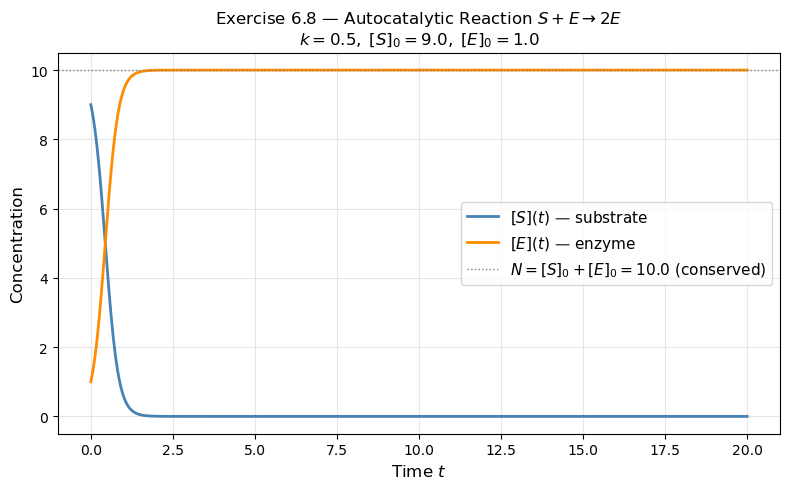

In [8]:
# --- Plot 1: Time series ---
fig, ax = plt.subplots(figsize=(8, 5))

ax.plot(sol.t, sol.y[0], label='$[S](t)$ — substrate', color='steelblue', linewidth=2)
ax.plot(sol.t, sol.y[1], label='$[E](t)$ — enzyme',    color='darkorange', linewidth=2)
ax.axhline(N, color='gray', linestyle=':', linewidth=1, label=f'$N = [S]_0+[E]_0 = {N}$ (conserved)')

ax.set_xlabel('Time $t$', fontsize=12)
ax.set_ylabel('Concentration', fontsize=12)
ax.set_title('Exercise 6.8 — Autocatalytic Reaction $S + E \\to 2E$\n'
             f'$k={k},\\; [S]_0={S0},\\; [E]_0={E0}$', fontsize=12)
ax.legend(fontsize=11)
ax.grid(alpha=0.3)
plt.tight_layout()
plt.show()

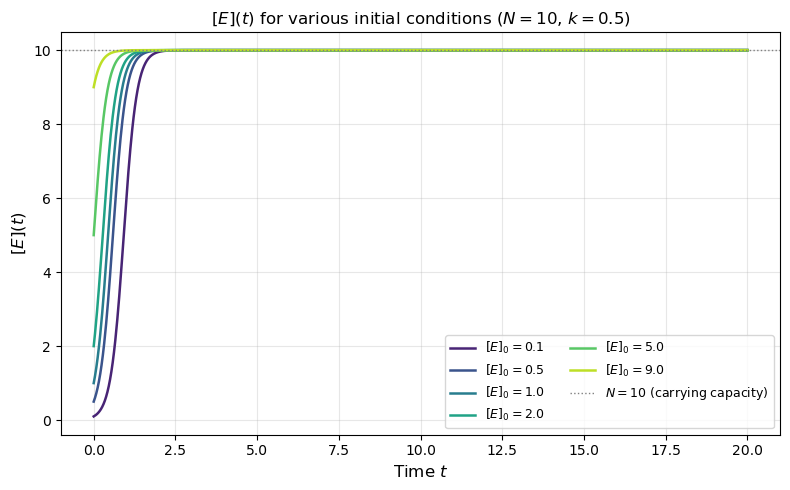

In [9]:
# --- Plot 2: Multiple initial conditions (varying E0) ---
fig, ax = plt.subplots(figsize=(8, 5))

E0_values = [0.1, 0.5, 1.0, 2.0, 5.0, 9.0]
colors = plt.cm.viridis(np.linspace(0.1, 0.9, len(E0_values)))

for E0_i, color in zip(E0_values, colors):
    S0_i = 10.0 - E0_i  # keep N = 10 fixed
    sol_i = solve_ivp(model, t_span, [S0_i, E0_i], args=(k,), t_eval=t_eval, rtol=1e-9)
    ax.plot(sol_i.t, sol_i.y[1], color=color, linewidth=1.8,
            label=f'$[E]_0 = {E0_i}$')

ax.axhline(10, color='gray', linestyle=':', linewidth=1, label='$N = 10$ (carrying capacity)')
ax.set_xlabel('Time $t$', fontsize=12)
ax.set_ylabel('$[E](t)$', fontsize=12)
ax.set_title('$[E](t)$ for various initial conditions ($N=10$, $k=0.5$)', fontsize=12)
ax.legend(fontsize=9, ncol=2)
ax.grid(alpha=0.3)
plt.tight_layout()
plt.show()

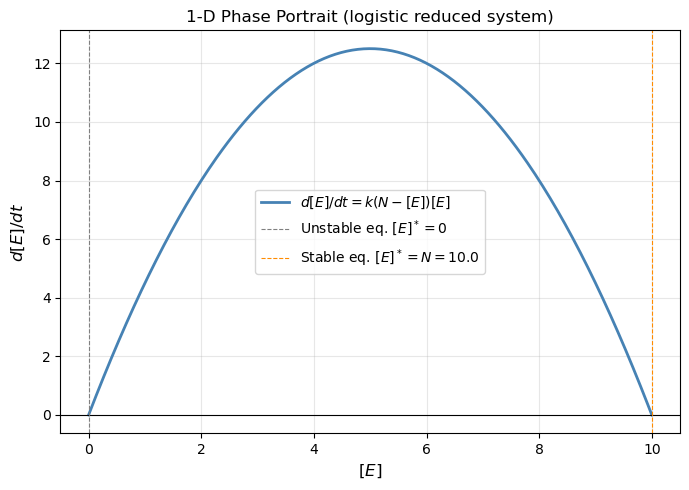

In [10]:
# --- Plot 3: Phase portrait on the conserved line S + E = N ---
fig, ax = plt.subplots(figsize=(7, 5))

# The entire dynamics live on the line S = N - E
E_range = np.linspace(0, N, 300)
S_range = N - E_range
dE_range = k * S_range * E_range  # = k*(N-E)*E  (logistic)

ax.plot(E_range, dE_range, color='steelblue', linewidth=2, label=r'$d[E]/dt = k(N-[E])[E]$')
ax.axhline(0, color='black', linewidth=0.8)
ax.axvline(0,   color='gray', linewidth=0.8, linestyle='--', label='Unstable eq. $[E]^*=0$')
ax.axvline(N,   color='darkorange', linewidth=0.8, linestyle='--', label=f'Stable eq. $[E]^*=N={N}$')

ax.set_xlabel('$[E]$', fontsize=12)
ax.set_ylabel('$d[E]/dt$', fontsize=12)
ax.set_title('1-D Phase Portrait (logistic reduced system)', fontsize=12)
ax.legend(fontsize=10)
ax.grid(alpha=0.3)
plt.tight_layout()
plt.show()

---

## Summary

| | |
|---|---|
| **Reaction** | $S + E \overset{k}{\to} 2E$ |
| **ODEs** | $d[S]/dt = -k[S][E]$, $\quad d[E]/dt = +k[S][E]$ |
| **Conservation law** | $[S](t) + [E](t) = N = \text{const}$ |
| **Reduced form** | $d[E]/dt = k(N - [E])[E]$ — logistic growth |
| **Stable equilibrium** | $([S]^*, [E]^*) = (0, N)$ — all substrate consumed |
| **Unstable equilibrium** | $([S]^*, [E]^*) = (N, 0)$ — no enzyme to start the reaction |

The autocatalytic reaction is self-reinforcing: more $E$ means faster conversion of $S$ into even more $E$. This positive feedback gives the characteristic logistic S-curve, identical in form to population growth with a resource limit.